# Produção de Energia no Brasil (2015–2024)

**Projeto G1 — Tema 6 · Notebook de análise exploratória**

| | |
|---|---|
| **Disciplina** | Linguagem de Programação — Análise e Visualização de Dados com Python |
| **Professor** | Alexandre Neves Louzada |
| **Aluno** | Enzo Ribas Torres |

Roteiro: 1. Introdução · 2. Contextualização energética · 3. Explicação da base · 4. Leitura dos dados ·
5. Limpeza e preparação · 6. Engenharia de atributos · 7. Análise exploratória · 8. KPIs · 9. Visualizações ·
10. Persistência em banco (SQLAlchemy + SQLite) · 11. Interpretação dos resultados · 12. Conclusão

## 1. Introdução

Este notebook investiga a **produção e o consumo de energia no Brasil entre 2015 e 2024**. O objetivo é responder
sete perguntas orientadoras:

1. Quais fontes energéticas predominam no Brasil?
2. Quais regiões produzem mais energia?
3. Houve crescimento da energia renovável?
4. Existe sazonalidade na geração?
5. Quais estados possuem maior produção?
6. Há redução da dependência hidrelétrica?
7. Como a matriz energética evoluiu ao longo do tempo?

Os resultados alimentam o dashboard Streamlit (`app.py`), que usa **Plotly** para os gráficos interativos. Aqui os
gráficos são estáticos (Matplotlib/Seaborn), para que apareçam também na visualização do notebook pelo GitHub.

## 2. Contextualização energética

A produção de energia é um dos principais indicadores de desenvolvimento econômico e de infraestrutura. O Brasil tem
uma das matrizes elétricas mais renováveis do mundo, historicamente apoiada nas **hidrelétricas**, e vem expandindo
**eólica** e **solar** na última década. As **termelétricas** (gás, carvão, óleo) entram como complemento, sobretudo em
períodos de seca, e são a principal fonte de emissões do setor elétrico. A única fonte nuclear do país são as usinas de
Angra, no Rio de Janeiro.

Analisar a matriz permite entender o crescimento da demanda, a sustentabilidade, a dependência de determinadas fontes,
a eficiência e os impactos ambientais da geração.

## 3. Explicação da base

A base `simulacao_producao_energia_brasil.csv` é **simulada** e foi fornecida pelo professor. Cada linha é um
**estado × fonte de energia × mês**.

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Ano, mês e data de referência (1º dia do mês) |
| `regiao`, `uf` | Localização |
| `fonte_energia` | Hidrelétrica, Eólica, Solar, Biomassa, Nuclear ou Termelétrica |
| `producao_mwh`, `consumo_mwh` | Energia produzida e consumida (MWh) |
| `capacidade_instalada` | Capacidade instalada |
| `emissao_co2` | Emissão estimada (toneladas de CO₂) |
| `custo_medio_mwh` | Custo médio (R$/MWh) |
| `percentual_renovavel` | Percentual renovável atribuído à fonte |
| `nivel_demanda` | Baixo, Médio, Alto ou Crítico |

O projeto também consome a **API de dados do IBGE** (nome oficial, código e malha geográfica dos estados).

## 4. Leitura dos dados

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DADOS = RAIZ / "dados"
IMAGENS = RAIZ / "imagens"
IMAGENS.mkdir(exist_ok=True)

FONTES = ["Hidrelétrica", "Eólica", "Solar", "Biomassa", "Nuclear", "Termelétrica"]
CORES_FONTE = {"Hidrelétrica": "#2a78d6", "Eólica": "#1baf7a", "Solar": "#eda100", "Biomassa": "#008300",
               "Nuclear": "#4a3aa7", "Termelétrica": "#eb6834"}
CORES_REGIAO = {"Norte": "#2a78d6", "Nordeste": "#eb6834", "Centro-Oeste": "#1baf7a", "Sudeste": "#eda100", "Sul": "#e87ba4"}
CORES_DEMANDA = {"Baixo": "#0ca30c", "Médio": "#fab219", "Alto": "#ec835a", "Crítico": "#d03b3b"}
DIVERGENTE = LinearSegmentedColormap.from_list("div", ["#d03b3b", "#f0efec", "#2a78d6"])
MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
TWH = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlesize": 13, "grid.color": "#e1e0d9",
    "legend.frameon": False, "figure.dpi": 100,
})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

df_bruto = pd.read_csv(DADOS / "simulacao_producao_energia_brasil.csv", encoding="utf-8-sig")
print(f"{df_bruto.shape[0]:,} linhas x {df_bruto.shape[1]} colunas".replace(",", "."))
df_bruto.head()

14.400 linhas x 13 colunas


,ano,mes,data,regiao,uf,fonte_energia,producao_mwh,consumo_mwh,capacidade_instalada,emissao_co2,custo_medio_mwh,percentual_renovavel,nivel_demanda
0,2015,1,2015-01-01,Norte,AM,Hidrelétrica,"80,517.98","88,545.10","112,725.18","3,220.72",190.27,95,Alto
1,2015,1,2015-01-01,Norte,AM,Eólica,"30,360.65","33,758.78","42,504.91","1,214.43",220.31,95,Alto
2,2015,1,2015-01-01,Norte,AM,Solar,"16,483.09","15,341.74","23,076.32",659.32,409.55,95,Médio
3,2015,1,2015-01-01,Norte,AM,Termelétrica,"37,984.27","41,240.83","53,177.98","24,689.78",346.92,10,Alto
4,2015,1,2015-01-01,Norte,AM,Biomassa,"22,243.62","24,886.82","31,141.07",889.74,286.56,95,Alto


In [2]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ano                   14400 non-null  int64  
 1   mes                   14400 non-null  int64  
 2   data                  14400 non-null  str    
 3   regiao                14400 non-null  str    
 4   uf                    14400 non-null  str    
 5   fonte_energia         14400 non-null  str    
 6   producao_mwh          14400 non-null  float64
 7   consumo_mwh           14400 non-null  float64
 8   capacidade_instalada  14400 non-null  float64
 9   emissao_co2           14400 non-null  float64
 10  custo_medio_mwh       14400 non-null  float64
 11  percentual_renovavel  14400 non-null  int64  
 12  nivel_demanda         14400 non-null  str    
dtypes: float64(5), int64(3), str(5)
memory usage: 1.9 MB


## 5. Limpeza e preparação

Verificações: nulos, duplicados pela chave estado × fonte × mês, coerência da data, valores negativos ou impossíveis,
valores artificiais, coerência das classificações e das variáveis derivadas.

In [3]:
print("Valores nulos:", int(df_bruto.isna().sum().sum()))
print("Duplicados (estado × fonte × mês):", df_bruto.duplicated(subset=["data", "uf", "fonte_energia"]).sum())
data = pd.to_datetime(df_bruto["data"])
print("Datas divergentes de ano/mês:", ((data.dt.year != df_bruto["ano"]) | (data.dt.month != df_bruto["mes"])).sum())
numericas = ["producao_mwh", "consumo_mwh", "capacidade_instalada", "emissao_co2", "custo_medio_mwh"]
print("Valores negativos:", int((df_bruto[numericas] < 0).sum().sum()))
print("Produção acima da capacidade:", (df_bruto["producao_mwh"] > df_bruto["capacidade_instalada"]).sum())
print("Cobertura: ", df_bruto["uf"].nunique(), "UFs ×", df_bruto["fonte_energia"].nunique(), "fontes ×",
      df_bruto["data"].nunique(), "meses =", df_bruto["uf"].nunique() * df_bruto["fonte_energia"].nunique() * df_bruto["data"].nunique())

Valores nulos: 0
Duplicados (estado × fonte × mês): 0
Datas divergentes de ano/mês: 0
Valores negativos: 0
Produção acima da capacidade: 0
Cobertura:  20 UFs × 6 fontes × 120 meses = 14400


In [4]:
# Valores mínimos suspeitos: a simulação usa um piso de 100 MWh
piso = df_bruto[df_bruto["producao_mwh"] <= 100]
print(f"Registros no piso de 100 MWh: {len(piso)}")
print(piso["fonte_energia"].value_counts().to_string())
piso[["data", "uf", "fonte_energia", "producao_mwh", "capacidade_instalada", "emissao_co2"]].head()

Registros no piso de 100 MWh: 452
fonte_energia
Nuclear     450
Biomassa      2


,data,uf,fonte_energia,producao_mwh,capacidade_instalada,emissao_co2
5,2015-01-01,AM,Nuclear,100.00,140.00,4.00
23,2015-01-01,TO,Nuclear,100.00,140.00,4.00
83,2015-01-01,SP,Nuclear,100.00,140.00,4.00
89,2015-01-01,RJ,Nuclear,100.00,140.00,4.00
131,2015-02-01,PA,Nuclear,100.00,140.00,4.00


In [5]:
# O campo percentual_renovavel é fixo por fonte
df_bruto.groupby("fonte_energia")["percentual_renovavel"].unique()

fonte_energia
Biomassa        [95]
Eólica          [95]
Hidrelétrica    [95]
Nuclear         [95]
Solar           [95]
Termelétrica    [10]
Name: percentual_renovavel, dtype: object

In [6]:
# Variáveis que deveriam variar, mas são proporções fixas na simulação
fatores = df_bruto.assign(
    fator_emissao=df_bruto["emissao_co2"] / df_bruto["producao_mwh"],
    fator_capacidade=df_bruto["producao_mwh"] / df_bruto["capacidade_instalada"],
).groupby("fonte_energia")[["fator_emissao", "fator_capacidade"]].agg(["min", "max"])
fatores

fator_emissao      fator_capacidade     
                        min  max              min  max
fonte_energia                                         
Biomassa               0.04 0.04             0.71 0.71
Eólica                 0.04 0.04             0.71 0.71
Hidrelétrica           0.04 0.04             0.71 0.71
Nuclear                0.04 0.04             0.71 0.71
Solar                  0.04 0.04             0.71 0.71
Termelétrica           0.65 0.65             0.71 0.71

In [7]:
# O nível de demanda segue faixas da razão consumo ÷ produção
indice = df_bruto["consumo_mwh"] / df_bruto["producao_mwh"]
df_bruto.assign(indice=indice).groupby("nivel_demanda")["indice"].agg(["min", "max", "count"]).sort_values("min")

,min,max,count
nivel_demanda,,,
Baixo,0.75,0.85,3602
Médio,0.85,1.00,5442
Alto,1.00,1.12,4320
Crítico,1.12,1.15,1036


In [8]:
df = df_bruto.copy()
for col in ["regiao", "uf", "fonte_energia", "nivel_demanda"]:
    df[col] = df[col].astype(str).str.strip()
df["uf"] = df["uf"].str.upper()
df["data"] = pd.to_datetime(df["data"])
df = df.drop_duplicates(subset=["data", "uf", "fonte_energia"])
df = df[(df[numericas] >= 0).all(axis=1) & (df["producao_mwh"] <= df["capacidade_instalada"])]

# Valores de piso: mantidos (somam 0,008% da produção), mas sinalizados para análises por fonte
df["valor_piso"] = df["producao_mwh"] <= 100

# Correção conceitual: nuclear não é renovável (usa urânio); o CSV atribui 95%
RENOVAVEIS = {"Hidrelétrica", "Eólica", "Solar", "Biomassa"}
df["renovavel"] = df["fonte_energia"].isin(RENOVAVEIS)
df["classe_fonte"] = np.select([df["renovavel"], df["fonte_energia"] == "Nuclear"], ["Renovável", "Nuclear"], "Fóssil")

df["fonte_energia"] = pd.Categorical(df["fonte_energia"], FONTES, ordered=True)
df["regiao"] = pd.Categorical(df["regiao"], list(CORES_REGIAO), ordered=True)
df["nivel_demanda"] = pd.Categorical(df["nivel_demanda"], list(CORES_DEMANDA), ordered=True)

print(f"Base tratada: {len(df):,} linhas · {df['valor_piso'].sum()} valores de piso sinalizados".replace(",", "."))
print(f"Piso representa {df.loc[df['valor_piso'], 'producao_mwh'].sum() / df['producao_mwh'].sum() * 100:.4f}% da produção")

Base tratada: 14.400 linhas · 452 valores de piso sinalizados
Piso representa 0.0079% da produção


**Resultado da limpeza:** a base não tem nulos, duplicados, datas incoerentes nem valores negativos. Foram encontrados
três pontos que exigem decisão:

- **452 registros no piso artificial de 100 MWh** (450 de nuclear e 2 de biomassa), sempre com capacidade 140 e emissão 4.
  Foram mantidos e sinalizados, pois somam menos de 0,01% da produção.
- **Nuclear marcada como 95% renovável.** Tecnicamente ela é não renovável (de baixa emissão). O percentual renovável do
  projeto é recalculado como produção de hidrelétrica, eólica, solar e biomassa ÷ produção total.
- **Proporções fixas:** o fator de emissão é 0,04 t/MWh para todas as fontes, exceto a termelétrica (0,65 t/MWh), e a produção
  é sempre 71,4% da capacidade. Essas variáveis são derivadas da produção e não trazem informação independente.

O nível de demanda é coerente com a razão consumo ÷ produção: Baixo < 0,85, Médio 0,85–1,00, Alto 1,00–1,12 e Crítico ≥ 1,12.

## 6. Engenharia de atributos

- `saldo_mwh` (produção − consumo) e `indice_demanda` (consumo ÷ produção);
- `fator_emissao` (t CO₂ por MWh);
- `trimestre`, `periodo_hidrologico` (chuvoso nov–abr; seco mai–out);
- `classe_fonte` (renovável, nuclear, fóssil);
- **integração com a API do IBGE**: nome oficial e código de cada UF.

In [9]:
df["saldo_mwh"] = df["producao_mwh"] - df["consumo_mwh"]
df["indice_demanda"] = df["consumo_mwh"] / df["producao_mwh"]
df["fator_emissao"] = df["emissao_co2"] / df["producao_mwh"]
df["trimestre"] = df["data"].dt.quarter
df["periodo_hidrologico"] = np.where(df["mes"].isin([11, 12, 1, 2, 3, 4]), "Chuvoso (nov–abr)", "Seco (mai–out)")

try:
    resposta = requests.get("https://servicodados.ibge.gov.br/api/v1/localidades/estados", timeout=15)
    resposta.raise_for_status()
    estados = pd.DataFrame([{"codigo_ibge": e["id"], "uf": e["sigla"], "nome": e["nome"], "regiao": e["regiao"]["nome"]}
                            for e in resposta.json()])
    print("Estados obtidos da API do IBGE:", len(estados))
except requests.RequestException:
    estados = pd.DataFrame(json.loads((DADOS / "ibge_estados.json").read_text(encoding="utf-8")))
    print("API indisponível: usando cópia local")

df = df.merge(estados[["uf", "nome", "codigo_ibge"]].rename(columns={"nome": "nome_uf"}), on="uf", how="left")
confere = df[["uf", "regiao"]].drop_duplicates().merge(estados[["uf", "regiao"]], on="uf", suffixes=("_csv", "_ibge"))
print("UFs sem correspondência:", df["nome_uf"].isna().sum(), "· regiões divergentes do IBGE:",
      (confere["regiao_csv"].astype(str) != confere["regiao_ibge"]).sum())
df[["data", "uf", "nome_uf", "fonte_energia", "classe_fonte", "producao_mwh", "saldo_mwh", "indice_demanda"]].head()

Estados obtidos da API do IBGE: 27
UFs sem correspondência: 0 · regiões divergentes do IBGE: 0


,data,uf,nome_uf,fonte_energia,classe_fonte,producao_mwh,saldo_mwh,indice_demanda
0,2015-01-01,AM,Amazonas,Hidrelétrica,Renovável,"80,517.98","-8,027.12",1.10
1,2015-01-01,AM,Amazonas,Eólica,Renovável,"30,360.65","-3,398.13",1.11
2,2015-01-01,AM,Amazonas,Solar,Renovável,"16,483.09","1,141.35",0.93
3,2015-01-01,AM,Amazonas,Termelétrica,Fóssil,"37,984.27","-3,256.56",1.09
4,2015-01-01,AM,Amazonas,Biomassa,Renovável,"22,243.62","-2,643.20",1.12


## 7. Análise exploratória

In [10]:
df[["producao_mwh", "consumo_mwh", "capacidade_instalada", "emissao_co2", "custo_medio_mwh", "indice_demanda"]].describe().T

,count,mean,std,min,25%,50%,75%,max
producao_mwh,"14,400.00","39,710.16","26,398.60",100.00,"22,234.26","35,584.21","48,898.07","123,344.30"
consumo_mwh,"14,400.00","37,709.04","25,677.57",75.15,"20,618.77","33,258.49","47,641.94","134,259.40"
capacidade_instalada,"14,400.00","55,594.23","36,958.04",140.00,"31,127.96","49,817.89","68,457.29","172,682.02"
emissao_co2,"14,400.00","6,061.92","10,453.86",4.00,897.66,"1,490.39","3,521.87","50,048.13"
custo_medio_mwh,"14,400.00",298.62,86.82,150.04,222.72,297.80,374.20,449.98
indice_demanda,"14,400.00",0.95,0.11,0.75,0.85,0.95,1.05,1.15


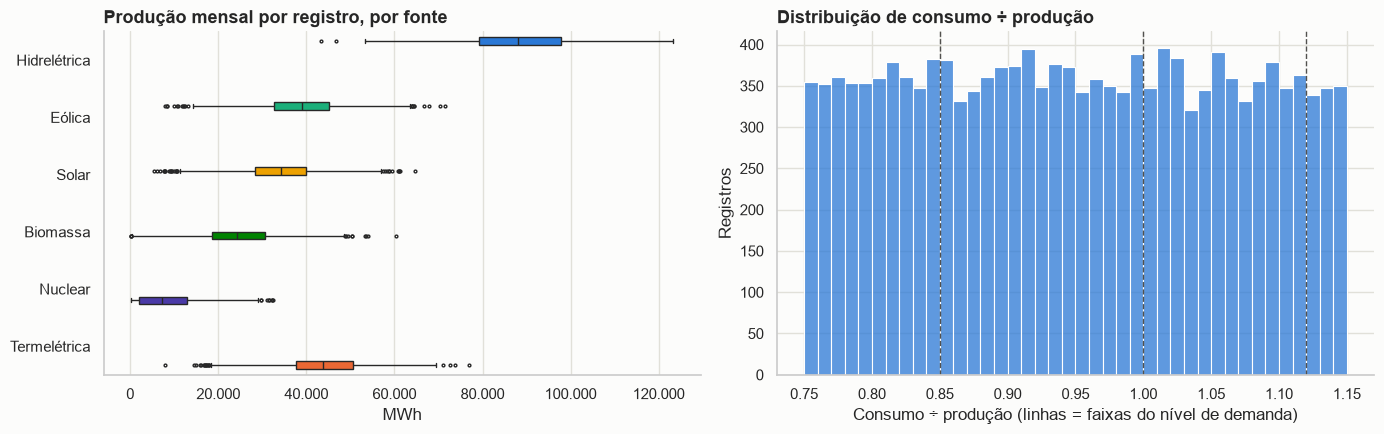

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, y="fonte_energia", x="producao_mwh", hue="fonte_energia", palette=CORES_FONTE, saturation=1,
            legend=False, fliersize=2, ax=axes[0])
axes[0].set_title("Produção mensal por registro, por fonte")
axes[0].set_xlabel("MWh")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(TWH)
sns.histplot(df["indice_demanda"], bins=40, color="#2a78d6", ax=axes[1])
for limite in [0.85, 1.0, 1.12]:
    axes[1].axvline(limite, color="#52514e", ls="--", lw=1)
axes[1].set_title("Distribuição de consumo ÷ produção")
axes[1].set_xlabel("Consumo ÷ produção (linhas = faixas do nível de demanda)")
axes[1].set_ylabel("Registros")
fig.tight_layout()
fig.savefig(IMAGENS / "distribuicoes.png", dpi=150, bbox_inches="tight")
plt.show()

A hidrelétrica tem os maiores volumes por registro; a nuclear, os menores (com muitos valores no piso). A razão
consumo ÷ produção é uniforme entre 0,75 e 1,15, ou seja, a simulação sorteia o consumo em torno da produção.

## 8. KPIs

In [12]:
producao = df["producao_mwh"].sum()
consumo = df["consumo_mwh"].sum()
emissao = df["emissao_co2"].sum()
por_fonte = df.groupby("fonte_energia", observed=True)["producao_mwh"].sum().sort_values(ascending=False)
por_uf = df.groupby(["uf", "nome_uf"])["producao_mwh"].sum().sort_values(ascending=False)
renovavel_pct = df.loc[df["renovavel"], "producao_mwh"].sum() / producao * 100
renovavel_csv = (df["producao_mwh"] * df["percentual_renovavel"]).sum() / producao

kpis = pd.DataFrame([
    ("Produção total de energia", f"{producao / 1e6:,.1f} TWh"),
    ("Fonte predominante", f"{por_fonte.index[0]} ({por_fonte.iloc[0] / producao * 100:.1f}%)"),
    ("Percentual renovável (nuclear não renovável)", f"{renovavel_pct:.1f}%"),
    ("Percentual renovável pelo campo do CSV (referência)", f"{renovavel_csv:.1f}%"),
    ("Estado com maior produção", f"{por_uf.index[0][1]} ({por_uf.iloc[0] / 1e6:.2f} TWh)"),
    ("Consumo total", f"{consumo / 1e6:,.1f} TWh"),
    ("Produção ÷ consumo", f"{producao / consumo * 100:.1f}%"),
    ("Emissão total de CO₂", f"{emissao / 1e6:.2f} Mt"),
    ("Intensidade de carbono", f"{emissao / producao * 1000:.0f} kg CO₂/MWh"),
], columns=["KPI", "Valor"])
kpis

,KPI,Valor
0,Produção total de energia,571.8 TWh
1,Fonte predominante,Hidrelétrica (37.1%)
2,Percentual renovável (nuclear não renovável),78.1%
3,Percentual renovável pelo campo do CSV (referê...,79.3%
4,Estado com maior produção,Espírito Santo (28.83 TWh)
5,Consumo total,543.0 TWh
6,Produção ÷ consumo,105.3%
7,Emissão total de CO₂,87.29 Mt
8,Intensidade de carbono,153 kg CO₂/MWh


## 9. Visualizações

### 9.1 Linha temporal: evolução da produção e do consumo

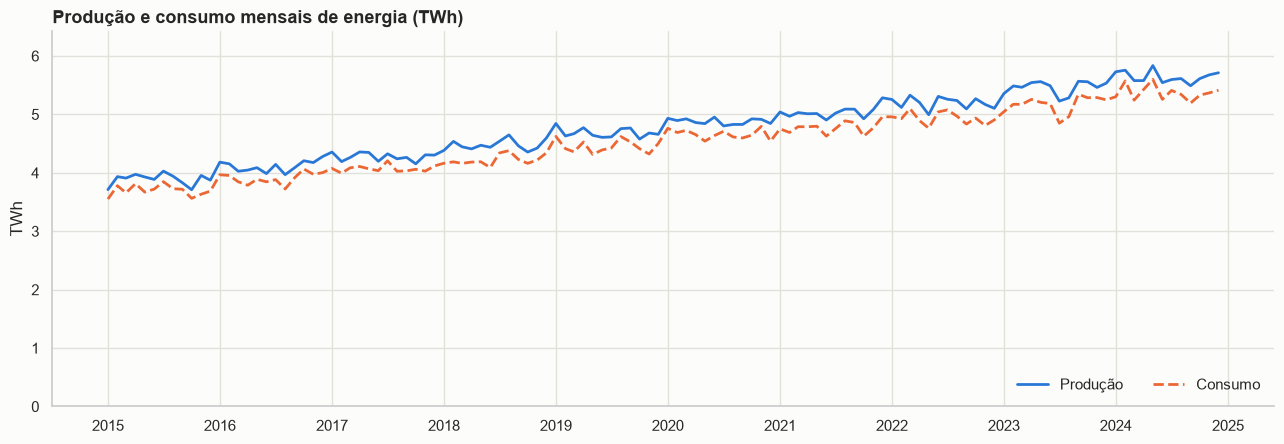

Crescimento anual composto: produção 4.22% · consumo 4.24%
Tendência linear (numpy.polyfit): +2.31 TWh por ano


,producao_mwh,consumo_mwh,crescimento_pct,media_movel_3a
ano,,,,
2015,46.68,44.36,NaN,46.68
2016,49.34,46.85,5.69,48.01
2017,51.30,48.83,3.98,49.11
2018,53.70,50.64,4.68,51.45
2019,56.22,53.44,4.68,53.74
2020,58.54,55.91,4.14,56.15
2021,60.45,57.30,3.27,58.40
2022,62.34,59.21,3.12,60.45
2023,65.53,62.01,5.12,62.77


In [13]:
mensal = df.groupby("data")[["producao_mwh", "consumo_mwh"]].sum() / 1e6
anual = df.groupby("ano")[["producao_mwh", "consumo_mwh", "emissao_co2"]].sum()

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(mensal.index, mensal["producao_mwh"], color="#2a78d6", lw=2, label="Produção")
ax.plot(mensal.index, mensal["consumo_mwh"], color="#eb6834", lw=2, ls="--", label="Consumo")
ax.set_title("Produção e consumo mensais de energia (TWh)")
ax.set_ylabel("TWh")
ax.set_ylim(0, mensal.max().max() * 1.1)
ax.legend(loc="lower right", ncol=2)
fig.tight_layout()
fig.savefig(IMAGENS / "evolucao_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

anos = anual.index.max() - anual.index.min()
cagr = lambda s: ((s.iloc[-1] / s.iloc[0]) ** (1 / anos) - 1) * 100
anual_tab = (anual[["producao_mwh", "consumo_mwh"]] / 1e6).assign(
    crescimento_pct=anual["producao_mwh"].pct_change() * 100,
    media_movel_3a=(anual["producao_mwh"] / 1e6).rolling(3, min_periods=1).mean(),
)
print(f"Crescimento anual composto: produção {cagr(anual['producao_mwh']):.2f}% · consumo {cagr(anual['consumo_mwh']):.2f}%")
print(f"Tendência linear (numpy.polyfit): {np.polyfit(anual.index, anual['producao_mwh'] / 1e6, 1)[0]:+.2f} TWh por ano")
anual_tab

A produção cresceu de 46,7 TWh (2015) para 67,7 TWh (2024): **+45%, ou 4,22% ao ano**, sem nenhum ano de queda. O consumo
acompanha de perto (4,24% ao ano) e fica sempre abaixo da produção. O maior salto foi em 2016 (+5,7%).

### 9.2 Barras por fonte e pizza da matriz energética

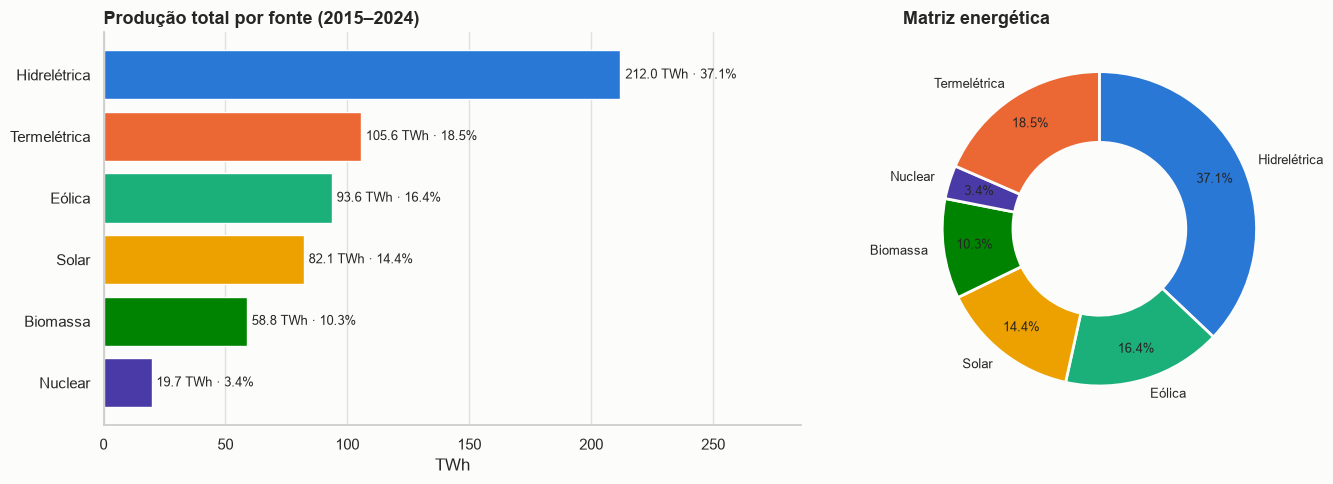

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.3, 1]})
twh = por_fonte / 1e6
axes[0].barh(twh.index.astype(str)[::-1], twh.values[::-1], color=[CORES_FONTE[f] for f in twh.index.astype(str)[::-1]])
for y, (v, p) in enumerate(zip(twh.values[::-1], (por_fonte / producao * 100).values[::-1])):
    axes[0].text(v + 2, y, f"{v:.1f} TWh · {p:.1f}%", va="center", fontsize=9)
axes[0].set_title("Produção total por fonte (2015–2024)")
axes[0].set_xlabel("TWh")
axes[0].set_xlim(0, twh.max() * 1.35)
axes[0].grid(axis="y", visible=False)

ordem = [f for f in FONTES if f in por_fonte.index]
axes[1].pie(por_fonte[ordem], labels=ordem, colors=[CORES_FONTE[f] for f in ordem], autopct="%1.1f%%", pctdistance=0.8,
            startangle=90, counterclock=False, wedgeprops=dict(width=0.45, edgecolor="#fcfcfb", linewidth=2),
            textprops=dict(fontsize=9))
axes[1].set_title("Matriz energética")
fig.tight_layout()
fig.savefig(IMAGENS / "matriz_fontes.png", dpi=150, bbox_inches="tight")
plt.show()

A **hidrelétrica predomina com 37,1%** da produção, seguida por termelétrica (18,5%), eólica (16,4%), solar (14,4%),
biomassa (10,3%) e nuclear (3,4%). Com nuclear corretamente classificada como não renovável, a matriz é **78,1% renovável**.

### 9.3 Evolução da matriz e da participação renovável

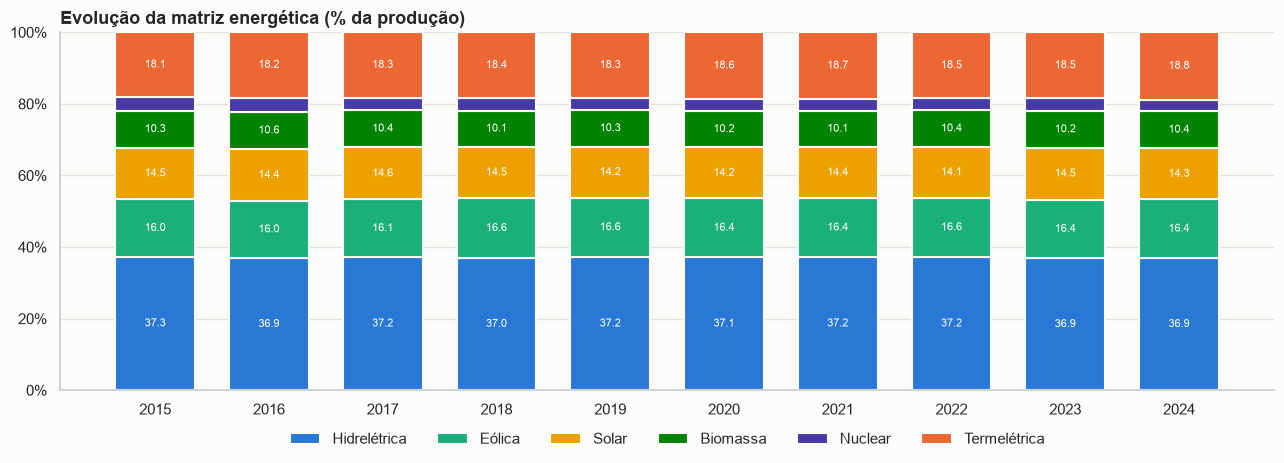

,renovavel_twh,renovavel_pct,hidreletrica_pct,termeletrica_pct
ano,,,,
2015,36.43,78.04,37.28,18.14
2016,38.40,77.84,36.92,18.24
2017,40.17,78.30,37.17,18.28
2018,41.95,78.11,36.97,18.42
2019,44.02,78.31,37.18,18.34
2020,45.66,77.99,37.13,18.64
2021,47.19,78.05,37.23,18.65
2022,48.81,78.31,37.18,18.50
2023,51.08,77.95,36.85,18.48


In [15]:
participacao = df.pivot_table(index="ano", columns="fonte_energia", values="producao_mwh", aggfunc="sum", observed=True)
participacao = participacao.div(participacao.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 4.8))
base = np.zeros(len(participacao))
for fonte in participacao.columns:
    ax.bar(participacao.index, participacao[fonte], bottom=base, color=CORES_FONTE[str(fonte)], label=str(fonte),
           edgecolor="#fcfcfb", linewidth=1.5, width=0.7)
    for x, (v, b) in enumerate(zip(participacao[fonte], base)):
        if v >= 8:
            ax.text(participacao.index[x], b + v / 2, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white")
    base += participacao[fonte].to_numpy()
ax.set_title("Evolução da matriz energética (% da produção)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(participacao.index)
ax.legend(ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(IMAGENS / "evolucao_matriz.png", dpi=150, bbox_inches="tight")
plt.show()

renov_ano = df[df["renovavel"]].groupby("ano")["producao_mwh"].sum()
resumo = pd.DataFrame({
    "renovavel_twh": renov_ano / 1e6,
    "renovavel_pct": renov_ano / anual["producao_mwh"] * 100,
    "hidreletrica_pct": participacao["Hidrelétrica"],
    "termeletrica_pct": participacao["Termelétrica"],
})
resumo

In [16]:
crescimento = pd.DataFrame({
    "crescimento_anual_pct": {str(f): cagr(df[df["fonte_energia"] == f].groupby("ano")["producao_mwh"].sum()) for f in FONTES},
    "participacao_2015": participacao.iloc[0].rename(str),
    "participacao_2024": participacao.iloc[-1].rename(str),
})
crescimento["variacao_pp"] = crescimento["participacao_2024"] - crescimento["participacao_2015"]
crescimento.sort_values("crescimento_anual_pct", ascending=False)

,crescimento_anual_pct,participacao_2015,participacao_2024,variacao_pp
Termelétrica,4.63,18.14,18.79,0.64
Eólica,4.47,16.05,16.40,0.35
Biomassa,4.42,10.25,10.43,0.18
Hidrelétrica,4.10,37.28,36.90,-0.38
Solar,4.05,14.46,14.25,-0.20
Nuclear,2.29,3.82,3.23,-0.59


**A matriz praticamente não mudou.** A produção renovável cresceu 45% em volume (36,4 → 52,8 TWh), mas sua participação
ficou em 78,0% no início e no fim da série. A participação hidrelétrica caiu só 0,38 p.p. (37,3% → 36,9%), dentro da
oscilação normal entre anos: **não houve redução relevante da dependência hidrelétrica**. A termelétrica foi a fonte que
mais cresceu (4,63% ao ano, +0,64 p.p.), e a nuclear a que menos cresceu (2,29% ao ano, −0,59 p.p.).

### 9.4 Sazonalidade: heatmap mensal

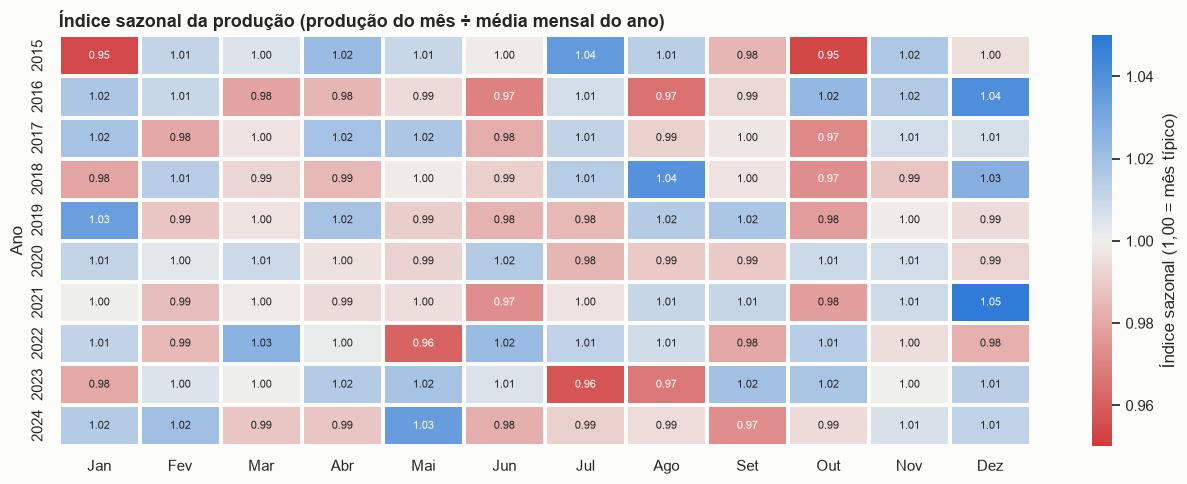

Amplitude do perfil médio: 2.0% · consistência entre anos: -0.05
Período chuvoso vs seco (produção média mensal, TWh):
periodo_hidrologico
Chuvoso (nov–abr)   4.78
Seco (mai–out)      4.75


In [17]:
mensal_ano = df.groupby(["ano", "mes"])["producao_mwh"].sum().reset_index()
mensal_ano["indice"] = mensal_ano["producao_mwh"] / mensal_ano.groupby("ano")["producao_mwh"].transform("mean")
tabela = mensal_ano.pivot(index="ano", columns="mes", values="indice")
tabela.columns = MESES

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(tabela, cmap=DIVERGENTE, center=1, vmin=0.95, vmax=1.05, annot=True, fmt=".2f", annot_kws={"fontsize": 8},
            linewidths=1.5, linecolor="#fcfcfb", cbar_kws={"label": "Índice sazonal (1,00 = mês típico)"}, ax=ax)
ax.set_title("Índice sazonal da produção (produção do mês ÷ média mensal do ano)")
ax.set_xlabel("")
ax.set_ylabel("Ano")
ax.grid(False)
fig.tight_layout()
fig.savefig(IMAGENS / "sazonalidade.png", dpi=150, bbox_inches="tight")
plt.show()

perfil = tabela.mean()
consistencia = np.mean([tabela.loc[a].corr(tabela.drop(index=a).mean()) for a in tabela.index])
print(f"Amplitude do perfil médio: {(perfil.max() - perfil.min()) * 100:.1f}% · consistência entre anos: {consistencia:.2f}")
print("Período chuvoso vs seco (produção média mensal, TWh):")
print((df.groupby(["ano", "mes", "periodo_hidrologico"])["producao_mwh"].sum().groupby("periodo_hidrologico").mean() / 1e6).round(3).to_string())

Dividir cada mês pela média do próprio ano remove o efeito do crescimento. O resultado: os meses variam só **2%** entre o
mais forte e o mais fraco, e o padrão **não se repete entre os anos** (consistência ≈ 0). Os períodos chuvoso e seco têm
produção média praticamente igual. **Não há sazonalidade relevante** nesta base. Em dados reais, a geração hidrelétrica e
a eólica variam fortemente com chuvas e ventos; a simulação não reproduz esse comportamento.

### 9.5 Barras por estado e comparação regional

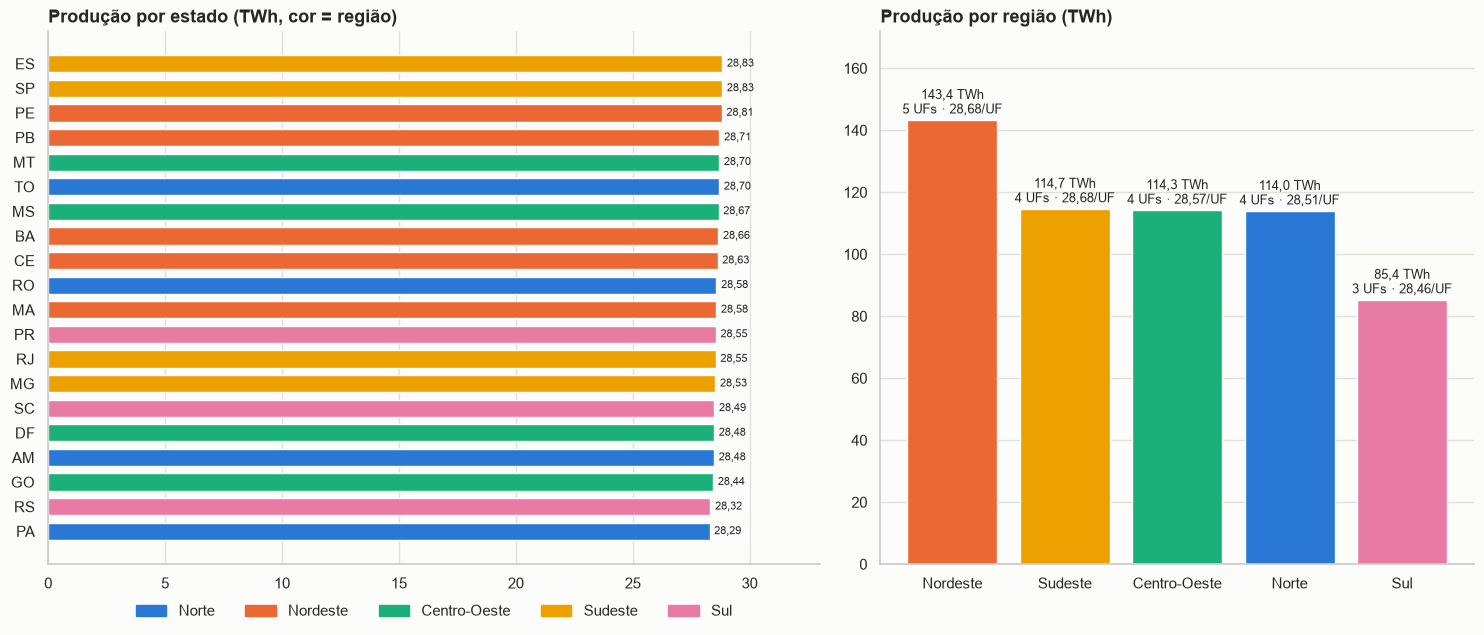

Diferença entre o maior e o menor estado: 1.9%


,producao,ufs,por_uf_twh
regiao,,,
Norte,"114,042,232.35",4,28.51
Nordeste,"143,383,436.66",5,28.68
Centro-Oeste,"114,292,877.47",4,28.57
Sudeste,"114,739,921.76",4,28.68
Sul,"85,367,876.36",3,28.46


In [18]:
uf_reg = df.groupby(["uf", "regiao"], observed=True)["producao_mwh"].sum().reset_index().sort_values("producao_mwh")
regioes = df.groupby("regiao", observed=True).agg(producao=("producao_mwh", "sum"), ufs=("uf", "nunique"))
regioes["por_uf_twh"] = regioes["producao"] / regioes["ufs"] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1.3, 1]})
axes[0].barh(uf_reg["uf"], uf_reg["producao_mwh"] / 1e6, color=[CORES_REGIAO[str(r)] for r in uf_reg["regiao"]], height=0.7)
for y, v in enumerate(uf_reg["producao_mwh"] / 1e6):
    axes[0].text(v + 0.2, y, f"{v:.2f}".replace(".", ","), va="center", fontsize=8)
axes[0].set_title("Produção por estado (TWh, cor = região)")
axes[0].set_xlim(0, 33)
axes[0].grid(axis="y", visible=False)
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in CORES_REGIAO.values()], labels=list(CORES_REGIAO),
               loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=5)

reg = regioes.sort_values("producao", ascending=False)
axes[1].bar(reg.index.astype(str), reg["producao"] / 1e6, color=[CORES_REGIAO[str(r)] for r in reg.index])
for x, (p, u, m) in enumerate(zip(reg["producao"] / 1e6, reg["ufs"], reg["por_uf_twh"])):
    axes[1].text(x, p + 2, f"{p:.1f} TWh\n{u} UFs · {m:.2f}/UF".replace(".", ","), ha="center", fontsize=9)
axes[1].set_title("Produção por região (TWh)")
axes[1].set_ylim(0, reg["producao"].max() / 1e6 * 1.2)
axes[1].grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(IMAGENS / "estados_regioes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Diferença entre o maior e o menor estado: {(uf_reg['producao_mwh'].max() / uf_reg['producao_mwh'].min() - 1) * 100:.1f}%")
regioes

Os estados produzem volumes **quase idênticos** (de 28,3 a 28,8 TWh, diferença de 1,9%). **Espírito Santo** e **São Paulo**
lideram por margem mínima. O **Nordeste** é a região que mais produz (143,4 TWh) só porque tem 5 estados na base; por
estado, todas as regiões ficam entre 28,5 e 28,7 TWh. Nesta base simulada, a desigualdade regional vem do número de
estados, não da produtividade.

### 9.6 Relação produção × consumo

Correlação produção × consumo (estado-mês): 0.922
Estados-mês com consumo > produção: 19.6%
Saldo por estado: de 1.20 a 1.65 TWh (nenhum estado deficitário)


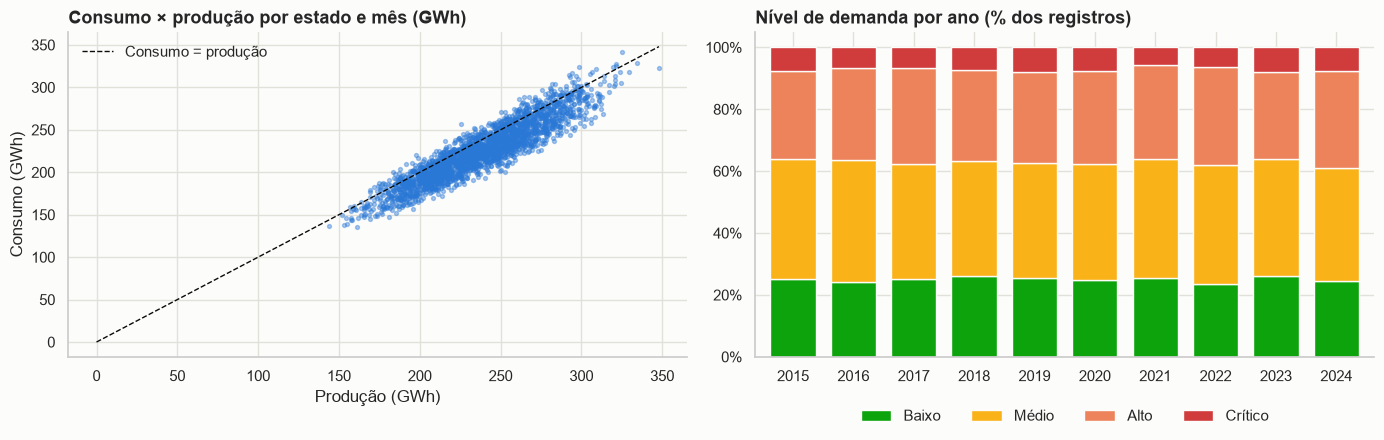

In [19]:
estado_mes = df.groupby(["uf", "data"])[["producao_mwh", "consumo_mwh"]].sum()
print(f"Correlação produção × consumo (estado-mês): {estado_mes['producao_mwh'].corr(estado_mes['consumo_mwh']):.3f}")
print(f"Estados-mês com consumo > produção: {(estado_mes['consumo_mwh'] > estado_mes['producao_mwh']).mean() * 100:.1f}%")
saldo_uf = (df.groupby("uf")["saldo_mwh"].sum() / 1e6).sort_values()
print(f"Saldo por estado: de {saldo_uf.min():.2f} a {saldo_uf.max():.2f} TWh (nenhum estado deficitário)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].scatter(estado_mes["producao_mwh"] / 1e3, estado_mes["consumo_mwh"] / 1e3, s=8, alpha=0.4, color="#2a78d6")
limite = estado_mes.max().max() / 1e3
axes[0].plot([0, limite], [0, limite], ls="--", color="#0b0b0b", lw=1, label="Consumo = produção")
axes[0].set_title("Consumo × produção por estado e mês (GWh)")
axes[0].set_xlabel("Produção (GWh)")
axes[0].set_ylabel("Consumo (GWh)")
axes[0].legend()
demanda = pd.crosstab(df["ano"], df["nivel_demanda"], normalize="index") * 100
demanda.plot(kind="bar", stacked=True, color=[CORES_DEMANDA[c] for c in demanda.columns], ax=axes[1], width=0.75,
             edgecolor="#fcfcfb")
axes[1].set_title("Nível de demanda por ano (% dos registros)")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(IMAGENS / "producao_consumo.png", dpi=150, bbox_inches="tight")
plt.show()

Produção e consumo andam juntos (correlação de 0,92). Em cerca de **20% dos estados-mês** o consumo supera a produção, mas
os déficits se compensam: no total, a produção cobre **105,3%** do consumo e todos os estados têm saldo positivo. Os
registros com demanda crítica (consumo ≥ 112% da produção) ficam entre 6% e 8% ao ano, sem tendência.

### 9.7 Dispersão emissão × produção: impacto ambiental

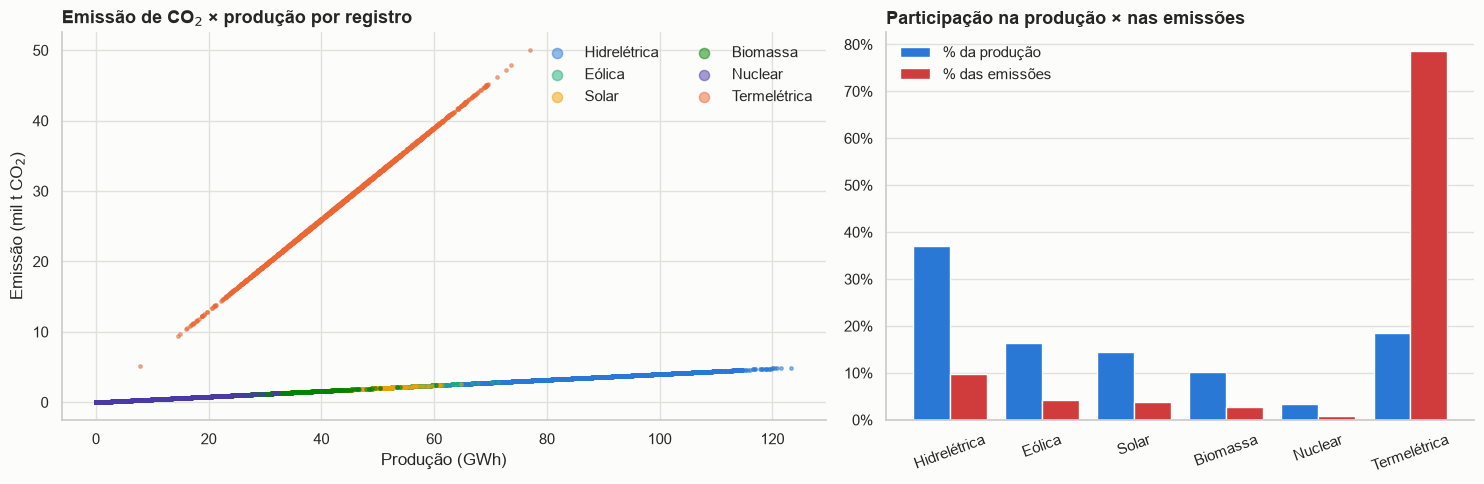

Emissões: 7.03 Mt (2015) → 10.47 Mt (2024), +48.8%


,producao_mwh,emissao_co2,kg_por_mwh,pct_producao,pct_emissao
fonte_energia,,,,,
Hidrelétrica,"212,002,307.26","8,480,092.27",40.00,37.07,9.71
Eólica,"93,615,898.56","3,744,635.92",40.00,16.37,4.29
Solar,"82,114,542.66","3,284,581.74",40.00,14.36,3.76
Biomassa,"58,793,777.80","2,351,751.21",40.00,10.28,2.69
Nuclear,"19,695,546.57","787,821.77",40.00,3.44,0.90
Termelétrica,"105,604,271.75","68,642,776.74",650.00,18.47,78.64


In [20]:
emis = df.groupby("fonte_energia", observed=True)[["producao_mwh", "emissao_co2"]].sum()
emis["kg_por_mwh"] = emis["emissao_co2"] / emis["producao_mwh"] * 1000
emis["pct_producao"] = emis["producao_mwh"] / emis["producao_mwh"].sum() * 100
emis["pct_emissao"] = emis["emissao_co2"] / emis["emissao_co2"].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.3, 1]})
for fonte in FONTES:
    sub = df[df["fonte_energia"] == fonte]
    axes[0].scatter(sub["producao_mwh"] / 1e3, sub["emissao_co2"] / 1e3, s=6, alpha=0.5, color=CORES_FONTE[fonte], label=fonte)
axes[0].set_title("Emissão de CO$_2$ × produção por registro")
axes[0].set_xlabel("Produção (GWh)")
axes[0].set_ylabel("Emissão (mil t CO$_2$)")
axes[0].legend(markerscale=3, ncol=2)
x = np.arange(len(emis))
axes[1].bar(x - 0.2, emis["pct_producao"], 0.4, color="#2a78d6", label="% da produção")
axes[1].bar(x + 0.2, emis["pct_emissao"], 0.4, color="#d03b3b", label="% das emissões")
axes[1].set_xticks(x, emis.index.astype(str), rotation=20)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Participação na produção × nas emissões")
axes[1].legend()
axes[1].grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(IMAGENS / "impacto_ambiental.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Emissões: {anual['emissao_co2'].iloc[0] / 1e6:.2f} Mt (2015) → {anual['emissao_co2'].iloc[-1] / 1e6:.2f} Mt (2024), "
      f"{(anual['emissao_co2'].iloc[-1] / anual['emissao_co2'].iloc[0] - 1) * 100:+.1f}%")
emis

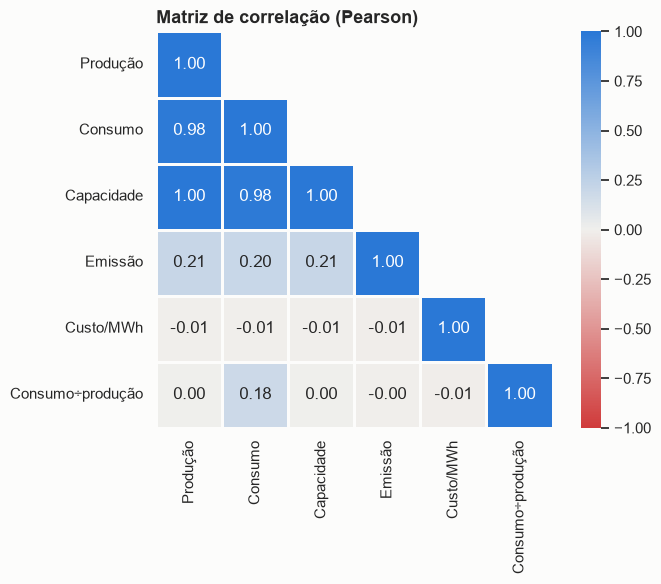

Custo médio por fonte (R$/MWh): {'Hidrelétrica': 299.0, 'Eólica': 300.5, 'Solar': 297.0, 'Biomassa': 296.5, 'Nuclear': 302.0, 'Termelétrica': 296.7}


In [21]:
corr = df[["producao_mwh", "consumo_mwh", "capacidade_instalada", "emissao_co2", "custo_medio_mwh", "indice_demanda"]].corr()
corr.columns = corr.index = ["Produção", "Consumo", "Capacidade", "Emissão", "Custo/MWh", "Consumo÷produção"]
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), cmap=DIVERGENTE, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", square=True, linewidths=2, linecolor="#fcfcfb", ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
ax.grid(False)
fig.tight_layout()
fig.savefig(IMAGENS / "matriz_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Custo médio por fonte (R$/MWh):", df.groupby("fonte_energia", observed=True)["custo_medio_mwh"].mean().round(1).to_dict())

Na dispersão, cada fonte forma uma reta cuja inclinação é o fator de emissão. A **termelétrica emite 650 kg de CO₂ por MWh,
16 vezes as demais fontes (40 kg/MWh)**. Por isso, com 18,5% da produção, ela responde por **78,6% das emissões**. As
emissões cresceram de 7,03 para 10,47 Mt por ano (+48,8%), um pouco mais rápido que a produção, porque a térmica cresceu
mais que as outras fontes.

O custo médio por MWh não tem relação com o volume produzido (r ≈ 0) e é praticamente igual entre as fontes, o que é uma
simplificação da simulação. A capacidade tem correlação 1 com a produção porque é derivada dela.

### 9.8 Tabela dinâmica: exploração detalhada

In [22]:
dinamica = df.pivot_table(index="regiao", columns="fonte_energia", values="producao_mwh", aggfunc="sum", observed=True) / 1e6
dinamica["Total"] = dinamica.sum(axis=1)
dinamica.style.background_gradient(cmap="Blues", axis=None, subset=FONTES).format("{:.1f}")

fonte_energia,Hidrelétrica,Eólica,Solar,Biomassa,Nuclear,Termelétrica,Total
regiao,,,,,,,
Norte,42.2,18.8,16.2,11.9,3.9,21.0,114.0
Nordeste,53.1,23.5,20.8,14.6,4.8,26.6,143.4
Centro-Oeste,42.4,18.5,16.4,11.7,4.2,21.0,114.3
Sudeste,42.6,18.7,16.4,11.8,3.9,21.3,114.7
Sul,31.7,14.0,12.3,8.8,2.9,15.7,85.4


## 10. Persistência em banco (SQLAlchemy + SQLite)

A base tratada é gravada em `database/producao_energia.sqlite` com **modelagem relacional** (SQLAlchemy ORM), usando o
mesmo módulo do dashboard (`src/banco.py`):

`regioes (1) ── (N) estados (1) ── (N) medicoes (N) ── (1) fontes_energia`

In [23]:
sys.path.insert(0, str(RAIZ))
from sqlalchemy import inspect, text

from src.banco import construir_banco
from src.dados import criar_atributos, limpar

base_banco = criar_atributos(limpar(df_bruto)[0], estados)
engine = construir_banco(base_banco, estados)
inspetor = inspect(engine)
for tabela in inspetor.get_table_names():
    with engine.connect() as conexao:
        n = conexao.execute(text(f"SELECT COUNT(*) FROM {tabela}")).scalar()
    print(f"{tabela:<16} {n:>6} linhas · FKs: {[fk['referred_table'] for fk in inspetor.get_foreign_keys(tabela)]}")

estados              20 linhas · FKs: ['regioes']
fontes_energia        6 linhas · FKs: []
medicoes          14400 linhas · FKs: ['estados', 'fontes_energia']
regioes               5 linhas · FKs: []


In [24]:
consulta = '''
SELECT f.classe,
       ROUND(SUM(m.producao_mwh) / 1e6, 1) AS producao_twh,
       ROUND(100.0 * SUM(m.producao_mwh) / (SELECT SUM(producao_mwh) FROM medicoes), 1) AS participacao_pct,
       ROUND(SUM(m.emissao_co2) / 1e6, 2) AS emissao_mt,
       ROUND(100.0 * SUM(m.emissao_co2) / (SELECT SUM(emissao_co2) FROM medicoes), 1) AS emissao_pct
FROM medicoes m
JOIN fontes_energia f ON f.id = m.fonte_id
GROUP BY f.classe
ORDER BY producao_twh DESC
'''
with engine.connect() as conexao:
    resultado_sql = pd.read_sql(text(consulta), conexao)
resultado_sql

,classe,producao_twh,participacao_pct,emissao_mt,emissao_pct
0,Renovável,446.50,78.10,17.86,20.50
1,Fóssil,105.60,18.50,68.64,78.60
2,Nuclear,19.70,3.40,0.79,0.90


In [25]:
colunas = ["ano", "mes", "data", "regiao", "uf", "nome_uf", "codigo_ibge", "fonte_energia", "classe_fonte", "producao_mwh",
           "consumo_mwh", "saldo_mwh", "indice_demanda", "capacidade_instalada", "emissao_co2", "fator_emissao",
           "custo_medio_mwh", "nivel_demanda", "periodo_hidrologico", "valor_piso"]
df[colunas].to_csv(DADOS / "producao_energia_tratada.csv", index=False, encoding="utf-8-sig")
print("Imagens geradas:", sorted(p.name for p in IMAGENS.glob("*.png")))

Imagens geradas: ['distribuicoes.png', 'estados_regioes.png', 'evolucao_matriz.png', 'evolucao_temporal.png', 'impacto_ambiental.png', 'matriz_correlacao.png', 'matriz_fontes.png', 'producao_consumo.png', 'sazonalidade.png']


## 11. Interpretação dos resultados

| Pergunta | Resposta |
|---|---|
| Quais fontes predominam? | **Hidrelétrica (37,1%)**, seguida por termelétrica (18,5%), eólica (16,4%), solar (14,4%), biomassa (10,3%) e nuclear (3,4%). |
| Quais regiões produzem mais? | **Nordeste** (143,4 TWh), mas só por ter 5 estados na base; por estado, todas as regiões produzem ≈ 28,6 TWh. |
| Houve crescimento da renovável? | **Em volume, sim (+45%)**; **em participação, não** (78,0% em 2015 e em 2024). |
| Existe sazonalidade? | **Não relevante**: amplitude de 2% e padrão que não se repete entre os anos. |
| Quais estados produzem mais? | **Espírito Santo e São Paulo** (28,8 TWh cada), mas a diferença para o último (Pará) é de só 1,9%. |
| Há redução da dependência hidrelétrica? | **Não**: 37,3% → 36,9% (−0,38 p.p.), dentro da oscilação normal. |
| Como a matriz evoluiu? | Cresceu 4,22% ao ano com **composição estável**; a termelétrica foi a que mais cresceu e as emissões subiram 48,8%. |

**Leitura crítica.** A base simulada tem proporções fixas (fator de emissão, fator de capacidade, participação das fontes
e produção por estado). Por isso, várias análises mostram estabilidade e ausência de padrão, e o resultado correto é
dizer isso, sem inventar tendências que os dados não mostram.

## 12. Conclusão

Entre 2015 e 2024 foram produzidos **571,8 TWh** e consumidos **543,0 TWh**. A produção cobre o consumo com folga (105,3%) e
cresce **4,22% ao ano**. A matriz é **78,1% renovável** e liderada pela hidrelétrica, mas **não está se transformando**:
as participações das fontes ficaram praticamente iguais em dez anos.

O principal ponto de atenção é o **impacto ambiental**: as emissões subiram 48,8%, e a termelétrica, com menos de um quinto
da produção, gera quase **79% do CO₂**.

**Recomendações:** substituir geração térmica por eólica e solar, em vez de apenas somar capacidade; diversificar para reduzir
a exposição a crises hídricas; monitorar estados e fontes com demanda crítica; e planejar a expansão para um crescimento de
cerca de 50% por década.

**Limitações:** a base é simulada e tem proporções fixas que não ocorrem no sistema real; nuclear foi reclassificada como
não renovável; a análise é descritiva (correlação não implica causalidade).